# Задание 6


## 📋 Описание задания
**Цель:** Бинарная классификация опухолей (злокачественная/доброкачественная)  
**Датасет:** Breast Cancer (569 образцов, 30 признаков)  
**Методы:** Pipeline + StandardScaler + LogisticRegression  
**Концепции:** Медицинская диагностика, несбалансированные классы, stratify


In [1]:
# ========================================================================
# ИМПОРТ И ЗАГРУЗКА BREAST CANCER DATASET
# ========================================================================
# Датасет для диагностики рака молочной железы
# 569 образцов, 30 признаков (радиус, текстура, периметр, площадь и т.д.)
# 2 класса: malignant (злокачественная), benign (доброкачественная)
# ========================================================================

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

df = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, random_state=42, test_size=0.3, stratify=df.target)
del df
del load_breast_cancer

In [2]:
# ========================================================================
# СОЗДАНИЕ PIPELINE
# ========================================================================
# 1. StandardScaler - нормализация 30 признаков
# 2. LogisticRegression(max_iter=1000):
#    - max_iter увеличен, т.к. данные сложные
#    - нужно больше итераций для сходимости градиентного спуска
# ========================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_5 = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter = 1000))
])

In [3]:
pipeline_5.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [18]:
y_pred, y_pred_proba = pipeline_5.predict(X_test), pipeline_5.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_auc_score, log_loss

In [20]:
def print_score(score_name: str, score, y_true, y_pred, **kwargs):
    print(score_name, ':', sep='')
    print(score(y_true, y_pred, **kwargs), end='\n\n')

In [21]:
def specifity_score(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    TN, FP = conf_matrix[0, 0], conf_matrix[0, 1]
    return (TN) / (TN + FP)

In [22]:
print_score('Accuracy', accuracy_score, y_test, y_pred)
print_score('Recall', recall_score, y_test, y_pred)
print_score('F1-score', f1_score, y_test, y_pred)
print_score('Specifity', specifity_score, y_test, y_pred)
print_score('Roc_Auc', roc_auc_score, y_test, y_pred_proba)

Accuracy:
0.9883040935672515

Recall:
0.9906542056074766

F1-score:
0.9906542056074766

Specifity:
0.984375

Roc_Auc:
0.9981016355140186



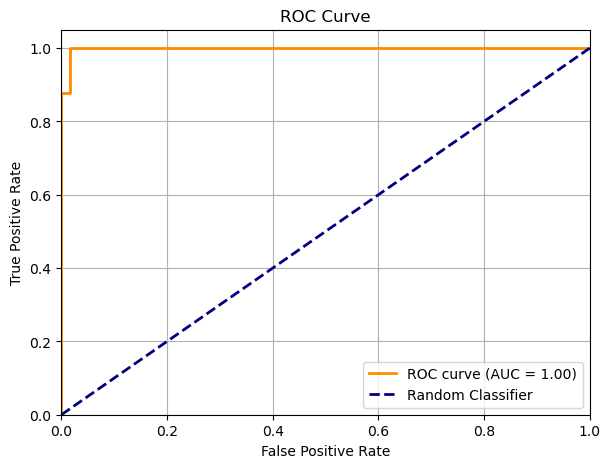

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)

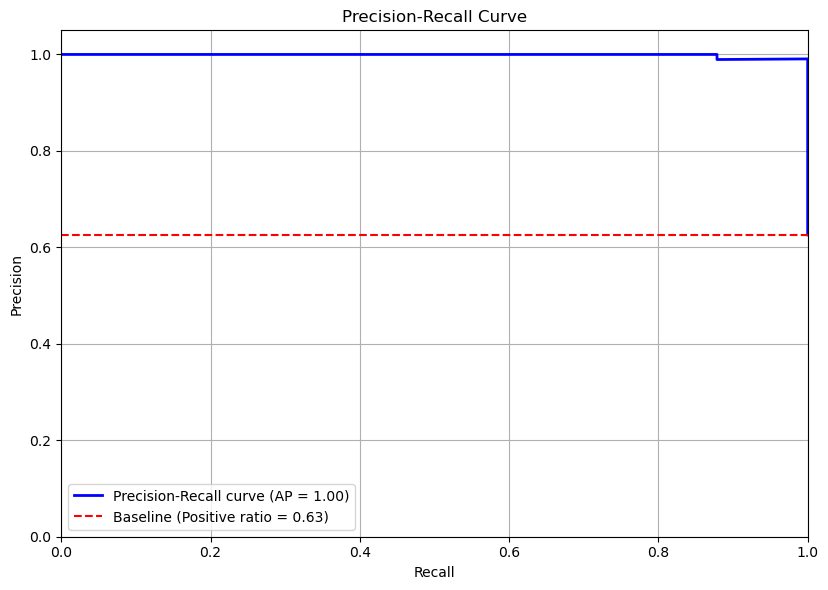

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, 
         label=f'Precision-Recall curve (AP = {average_precision:.2f})')

baseline = len(y_test[y_test==1]) / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', 
           label=f'Baseline (Positive ratio = {baseline:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
import joblib

joblib.dump(pipeline_5,'saved models/logistic_6.joblib')

['saved models/logistic_6.joblib']

In [40]:
del pipeline_5

In [41]:
pipeline_6 = joblib.load('saved models/logistic_6.joblib')

In [44]:
y_pred, y_pred_proba = pipeline_6.predict(X_test), pipeline_6.predict_proba(X_test)[:, 1]

print_score('Accuracy', accuracy_score, y_test, y_pred)
print_score('Recall', recall_score, y_test, y_pred)
print_score('F1-score', f1_score, y_test, y_pred)
print_score('Specifity', specifity_score, y_test, y_pred)
print_score('Roc_Auc', roc_auc_score, y_test, y_pred_proba)

Accuracy:
0.9883040935672515

Recall:
0.9906542056074766

F1-score:
0.9906542056074766

Specifity:
0.984375

Roc_Auc:
0.9981016355140186



In [50]:
sample = [X_test[0]]  # или sample = [X_test.iloc[0].values]
print(pipeline_6.predict(sample), pipeline_6.predict_proba(sample))

[0] [[0.96788105 0.03211895]]


> Какая метрика наиболее важна в медицинской диагностике рака? Почему?

> Что означает высокий recall для класса «злокачественная опухоль»?

> Что означает низкая specificity? Почему specificity тоже важна (ложноположительные диагнозы)?

> Почему accuracy может вводить в заблуждение?

# Ответы на вопросы по метрикам и deployment моделей

## 1. Почему в задаче диагностики рака recall для злокачественного класса важнее accuracy?

**Приоритет recall в медицинской диагностике:**
- Ложноотрицательные результаты (пропуск рака) опаснее ложноположительных
- Высокий recall означает меньше пропущенных случаев заболевания
- Accuracy может быть высокой при низком recall для злокачественного класса
- Стоимость ошибки: пропуск рака > ложная тревога

**Пример:**
- 98% accuracy при 70% recall для рака - опасно
- 90% accuracy при 100% recall для рака - предпочтительнее

## 2. Как вычисляется specificity, и почему её нельзя игнорировать в медицинских задачах?

**Specificity (специфичность):**
- TN / (TN + FP) - доля правильно идентифицированных отрицательных случаев
- Измеряет способность модели правильно определять здоровых пациентов

**Важность в медицине:**
- Высокая specificity снижает количество ложных тревог
- Предотвращает ненужные дополнительные обследования
- Снижает психологическую нагрузку на пациентов
- Оптимизирует использование медицинских ресурсов

## 3. Почему log-loss учитывает не только правильность предсказания, но и уверенность модели?

**Механизм log-loss:**
- Штрафует за высокую уверенность в неправильном предсказании
- Наказывает за низкую уверенность в правильном предсказании
- Учитывает распределение вероятностей по всем классам

**Пример:**
- Предсказание [0.9, 0.1] при правильном классе 0 → низкий штраф
- Предсказание [0.9, 0.1] при правильном классе 1 → высокий штраф
- Предсказание [0.6, 0.4] при правильном классе 0 → средний штраф

## 4. Какое значение ROC-AUC говорит о том, что модель «лучше случайного угадывания»?

**Интерпретация ROC-AUC:**
- ROC-AUC = 0.5 → модель не лучше случайного угадывания
- ROC-AUC > 0.5 → модель имеет предсказательную способность
- ROC-AUC = 1.0 → идеальная модель
- ROC-AUC < 0.5 → модель хуже случайного угадывания

**Пороговые значения:**
- 0.9-1.0: отличное качество
- 0.8-0.9: хорошее качество
- 0.7-0.8: удовлетворительное качество
- 0.6-0.7: плохое качество
- 0.5-0.6: очень плохое качество

## 5. Почему при сохранении модели с помощью joblib важно сохранять весь конвейер (pipeline), а не только объект LogisticRegression?

**Преимущества сохранения pipeline:**
- Гарантирует идентичную предобработку при развертывании
- Сохраняет параметры масштабирования (средние, стандартные отклонения)
- Исключает рассинхронизацию шагов предобработки
- Упрощает deployment - одна модель вместо нескольких компонентов
- Обеспечивает воспроизводимость результатов

## 6. Что произойдёт, если применить загруженный конвейер (pipeline) к новым данным без предварительного масштабирования? Почему?

**Последствия отсутствия масштабирования:**
- Модель получит данные в неправильном масштабе
- Предсказания будут некорректными и ненадежными
- Нарушится согласованность с обучением модели
- Коэффициенты логистической регрессии рассчитаны для масштабированных данных

**Причина:**
- Pipeline ожидает сырые данные и сам выполняет все преобразования
- Масштабирование - неотъемлемая часть workflow
- Параметры StandardScaler сохранены в pipeline и применяются автоматически

## 7. Можно ли использовать этот конвейер (pipeline) для предсказания на данных от другого медицинского центра? Какие риски это несёт?

**Технически можно, но с рисками:**

**Риски:**
- Разное распределение данных между центрами
- Другой протокол сбора и измерения показателей
- Смещение в данных (data drift)
- Снижение качества предсказаний

**Необходимые проверки:**
- Валидация на локальных данных медицинского центра
- Проверка распределения признаков
- Калибровка модели на новых данных
- Оценка метрик качества на репрезентативной выборке